<a href="https://colab.research.google.com/github/ahmadmustaffa/MultivariateLinearRegression_Colab/blob/main/multivariate_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("technoflask/multivariate-linear-regression-dataset")

Using Colab cache for faster access to the 'multivariate-linear-regression-dataset' dataset.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List files in the dataset directory

files = os.listdir(path)
print(f"Files in dataset: {files}")

# Assuming there is a CSV file, we will load the first one found

csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    display(df.head())
else:
    print("No CSV files found in the dataset directory.")

Files in dataset: ['Multivariate_Linear_Regression.csv']


,X1,X2,X3,X4,y
0,20.631730,12.867703,8.395460,13.990905,189.031908
1,4.101116,5.433219,3.563688,7.586737,65.410833
2,11.924915,-4.457952,4.307833,-3.869729,34.669369
3,33.079571,13.541840,0.573275,5.720989,189.053144
4,23.595950,14.390700,2.435688,28.890003,215.060877


### Data Overview
Let's check the data types, missing values, and descriptive statistics.

In [ ]:
# Dataset info and missing values
print("--- Info ---")
df.info()
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Descriptive statistics
print("\n--- Statistics ---")
display(df.describe())

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      5000 non-null   float64
 1   X2      5000 non-null   float64
 2   X3      5000 non-null   float64
 3   X4      5000 non-null   float64
 4   y       5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB

--- Missing Values ---
X1    0
X2    0
X3    0
X4    0
y     0
dtype: int64

--- Statistics ---


,X1,X2,X3,X4,y
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,22.663415,15.083334,4.966898,12.624664,194.586527
std,15.817222,11.599067,5.726316,10.171455,86.737743
min,-4.976895,-4.999482,-4.996529,-4.999851,-52.207438
25%,8.908293,5.139366,-0.055639,3.877419,131.157467
50%,22.535634,15.171626,4.997043,12.832065,194.676329
75%,36.587648,25.233339,9.893794,21.527947,258.002962
max,49.998196,34.994327,14.995766,29.999219,424.786090


### Visualizing Distributions and Relationships
I'll generate a pairplot to see relationships between features and histograms to check distributions.

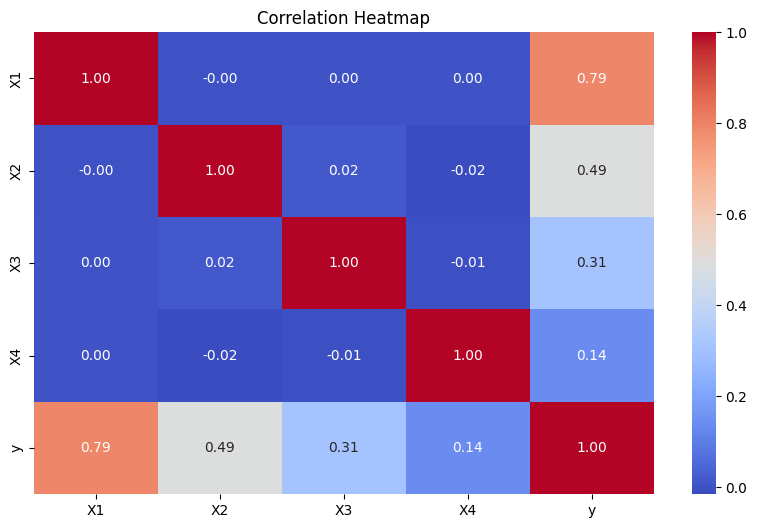

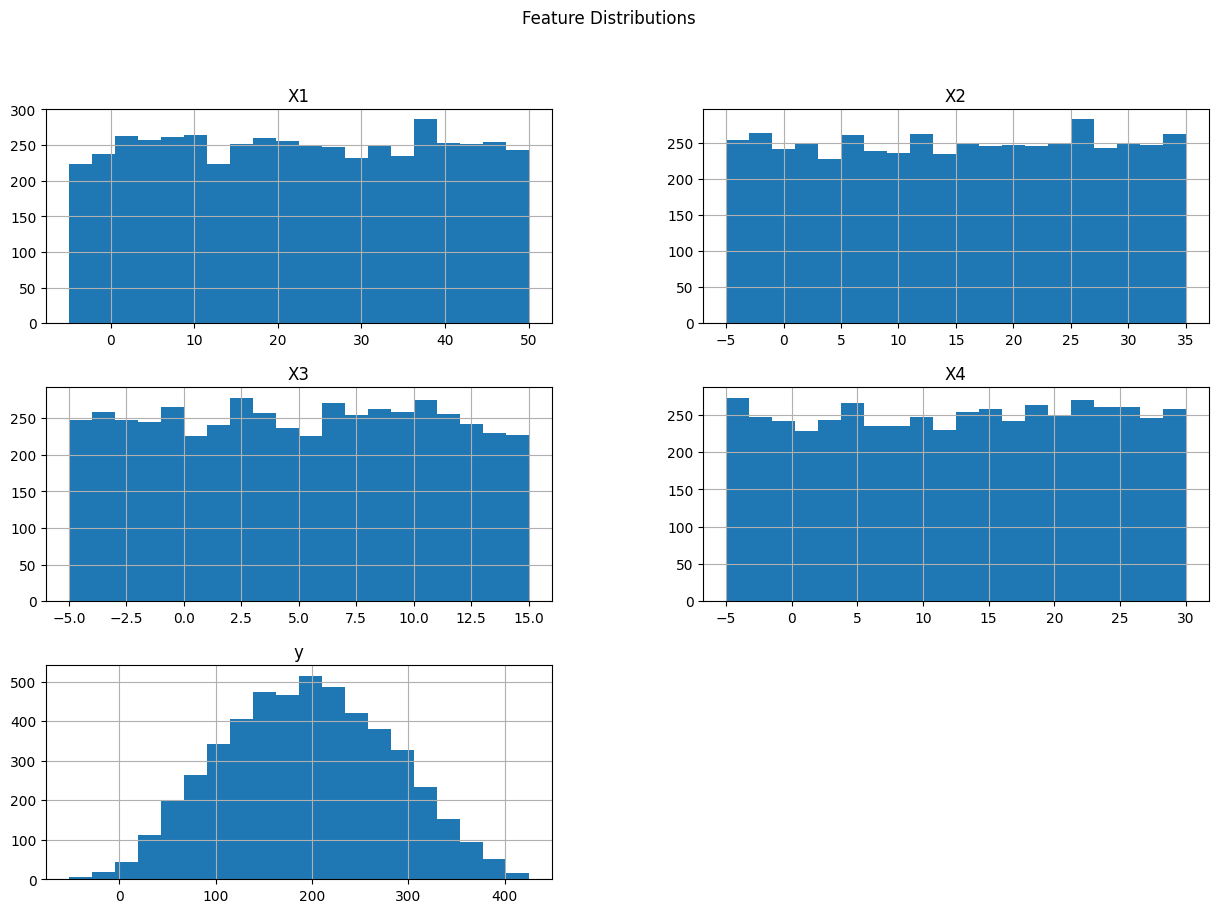

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Distribution of the target variable and features
df.hist(bins=20, figsize=(15, 10))
plt.suptitle('Feature Distributions')
plt.show()

### Data Pre-processing and Model Training
We will split the data into features (X) and target (y), followed by a train-test split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Splitting features and target
X = df.drop('y', axis=1)
y = df['y']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


### Model Evaluation
Now we evaluate the model using R² and MSE, and visualize the predictions against actual values.

Mean Squared Error: 134.6829
R-squared Score: 0.9821


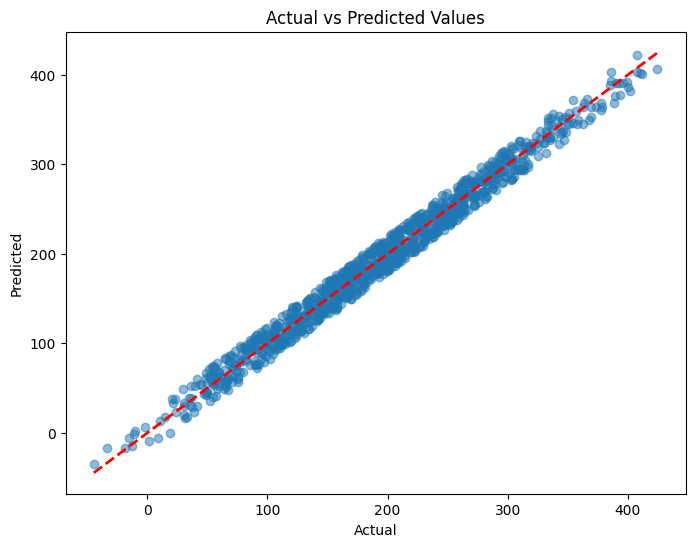

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# Visualize Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')
plt.show()